# Feature Selection — Titanic Dataset

This notebook uses:

```text
titanic_transformed_scaled.csv
```

Feature Selection means choosing useful features from the existing dataset and identifying features that may be irrelevant or redundant.

In this Titanic dataset, we will inspect the available features and demonstrate the basic techniques used to evaluate feature importance. We will not force-drop a feature when there is no clear reason to do so.

## 1. Import Libraries

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import accuracy_score

pd.set_option("display.max_columns", None)

## 2. Load the Dataset

Place `titanic_transformed_scaled.csv` in the same folder as this notebook.

In [19]:
df = pd.read_csv("../../Dataset/titanic_transformed-Scaled.csv")
df.head()

,Fare,Age,Pclass,SibSp,Parch,Sex_male,Embarked_Q,Embarked_S,Survived
0,-0.312011,-0.565736,1.0,0.125,0.0,1.0,0.0,1.0,0
1,2.461242,0.663861,0.0,0.125,0.0,0.0,0.0,0.0,1
2,-0.282777,-0.258337,1.0,0.000,0.0,0.0,0.0,1.0,1
3,1.673732,0.433312,0.0,0.125,0.0,0.0,0.0,1.0,1
4,-0.277363,0.433312,1.0,0.000,0.0,1.0,0.0,1.0,0


## 3. Inspect the Features

In [20]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (891, 9)

Columns:
['Fare', 'Age', 'Pclass', 'SibSp', 'Parch', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Survived']

Data types:
Fare          float64
Age           float64
Pclass        float64
SibSp         float64
Parch         float64
Sex_male      float64
Embarked_Q    float64
Embarked_S    float64
Survived        int64
dtype: object


## 4. Separate Features and Target

`Survived` is the target variable. All remaining columns are candidate input features.

In [21]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['Fare', 'Age', 'Pclass', 'SibSp', 'Parch', 'Sex_male', 'Embarked_Q', 'Embarked_S']
Target: Survived


## 5. What Is Feature Selection?

Feature selection chooses a useful subset of the **existing features**.

```text
Feature Selection
│
├── Filter Methods
│   ├── Correlation
│   ├── Variance
│   └── Statistical Tests
│
├── Wrapper Methods
│   ├── Forward Selection
│   ├── Backward Elimination
│   └── RFE
│
└── Embedded Methods
    ├── L1 Regularization
    └── Tree-based Feature Importance
```

## 6. Variance Check

A feature with no variation carries no information. `VarianceThreshold` can identify constant features.

In [22]:
variance_selector = VarianceThreshold(threshold=0)
variance_selector.fit(X)

constant_features = X.columns[~variance_selector.get_support()]

print("Constant features:")
print(constant_features.tolist())

Constant features:
[]


## 7. Correlation Analysis

Correlation can help identify highly related features and possible redundancy.

A high correlation does not automatically mean a feature must be removed.

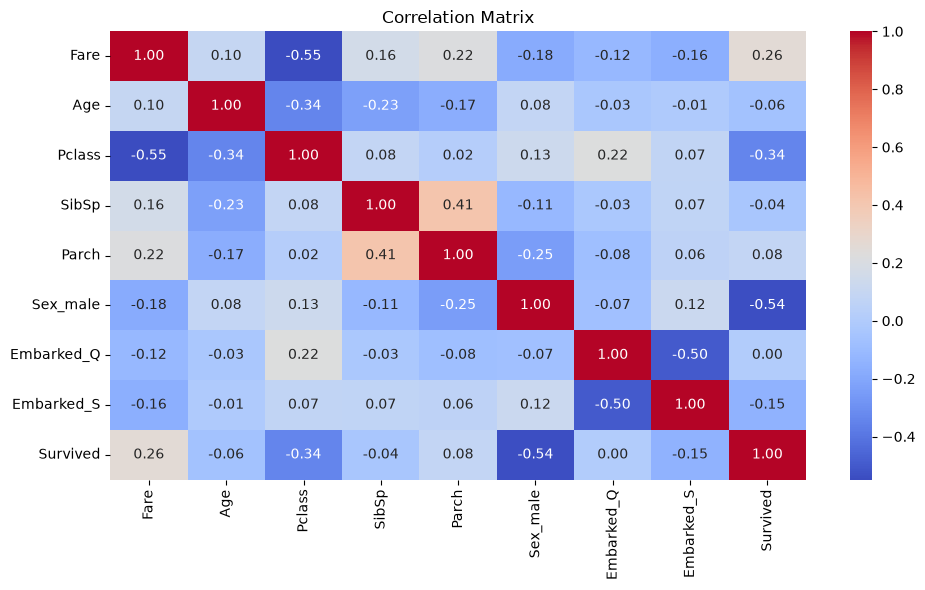

In [23]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 8. Statistical Selection — `SelectKBest`

For classification, `f_classif` can rank features using an ANOVA F-test.

Here we select the top 5 features only for demonstration. This does not mean these are automatically the final best features.

In [24]:
k = min(5, X.shape[1])

selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
}).sort_values("Score", ascending=False)

display(feature_scores)

selected_features = X.columns[selector.get_support()]
print("Top selected features:", selected_features.tolist())

,Feature,Score
5,Sex_male,372.405724
2,Pclass,115.031272
0,Fare,63.030764
7,Embarked_S,20.374460
4,Parch,5.963464
1,Age,3.761528
3,SibSp,1.110572
6,Embarked_Q,0.011846


Top selected features: ['Fare', 'Pclass', 'Parch', 'Sex_male', 'Embarked_S']


## 9. Embedded Selection — Random Forest

Tree-based models provide feature-importance scores.

These scores are model-specific, so they should be used as one source of evidence rather than absolute truth.

In [25]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance)

,Feature,Importance
0,Fare,0.274074
5,Sex_male,0.259963
1,Age,0.257455
2,Pclass,0.087020
3,SibSp,0.050315
4,Parch,0.039313
7,Embarked_S,0.021893
6,Embarked_Q,0.009966


## 10. Should We Drop a Feature?

There is no feature here that we need to drop automatically just because it exists.

In particular:

- `Name` and `Ticket` may contain useful information, but their raw text is better handled through **Feature Extraction**.
- The binary encoded features may still be useful.
- A feature should be removed when there is evidence that it is irrelevant, redundant, constant, noisy, or harmful to the model.

So for this notebook, we keep the dataset intact and focus on how feature selection is evaluated.

## 11. Evaluate Feature Selection

The most practical way to evaluate a selection is to compare model performance.

```text
All Features
     ↓
Train + Evaluate
     ↓
Selected Features
     ↓
Train + Evaluate
     ↓
Compare Results
```

Use the same validation setup for a fair comparison.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model_all = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_all.fit(X_train, y_train)

pred_all = model_all.predict(X_test)
accuracy_all = accuracy_score(y_test, pred_all)

print("Accuracy using all features:", round(accuracy_all, 4))

Accuracy using all features: 0.8268


## 12. Evaluate the Selected Features

In [27]:
selected_features = selected_features.tolist()

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

model_selected = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_selected.fit(X_train_selected, y_train)

pred_selected = model_selected.predict(X_test_selected)
accuracy_selected = accuracy_score(y_test, pred_selected)

print("Accuracy using selected features:", round(accuracy_selected, 4))

Accuracy using selected features: 0.7933


## 13. Interpreting the Comparison

Compare:

```python
print("All features:", accuracy_all)
print("Selected features:", accuracy_selected)
```

A good feature-selection result may:

- Maintain similar performance with fewer features
- Improve validation performance
- Reduce complexity
- Improve interpretability

Do not select features based only on one metric or one split. Cross-validation is preferred for a more reliable comparison.

## 14. Avoid Data Leakage

Feature selection should be learned from the **training data only**.

Correct workflow:

```text
Train / Test Split
      ↓
Feature Selection on TRAIN
      ↓
Apply same selection to TEST
      ↓
Evaluate
```

Do not select features using the full dataset before splitting.

## Key Takeaways

- Feature Selection chooses useful features from the existing dataset.
- Main approaches: Filter, Wrapper, and Embedded methods.
- Variance can identify constant features.
- Correlation can reveal redundancy.
- `SelectKBest` provides statistical feature ranking.
- Tree-based models provide feature importance.
- No arbitrary feature is dropped in this Titanic dataset.
- Evaluate selection by comparing model performance with the selected and full feature sets.
- Use cross-validation for stronger evaluation.
- Perform selection using training data only.

### Next

```text
Feature Selection
        ↓
Feature Extraction
        ↓
Feature Transformation
        ↓
Final ML Dataset
```